<a href="https://colab.research.google.com/github/Raghav-Pareek15048/Fraud-Detection-Project/blob/main/notebooks/Fraud_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<!-- Original '1. Project Overview & Problem Statement' section, content moved to a consolidated introduction. -->

# Financial Transaction Fraud Detection System

## 1. Project Introduction

This project focuses on building a robust system to detect fraudulent credit card transactions, a critical task in the financial sector. We address the challenge of class imbalance, where fraud cases are significantly outnumbered by legitimate transactions, and compare various machine learning models to identify the most effective solution.

<!-- Original '2. Data Loading' section, content moved to a consolidated introduction. -->

## 2. Data Ingestion

We begin by loading the `creditcard.csv` dataset, which contains anonymized transaction data. Understanding the initial structure and data types is crucial for subsequent preprocessing steps. The dataset includes PCA-transformed features (V1-V28) for privacy, along with 'Time' and 'Amount' features.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score, accuracy_score, precision_score, recall_score

# Load dataset
df = pd.read_csv('/content/creditcard.csv')

print(f"Dataset Shape: {df.shape}")
display(df.head())
print(df.info())
print("\nData Types:")
print(df.dtypes)

Dataset Shape: (277215, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 277215 entries, 0 to 277214
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    277215 non-null  float64
 1   V1      277215 non-null  float64
 2   V2      277215 non-null  float64
 3   V3      277215 non-null  float64
 4   V4      277215 non-null  float64
 5   V5      277215 non-null  float64
 6   V6      277215 non-null  float64
 7   V7      277215 non-null  float64
 8   V8      277215 non-null  float64
 9   V9      277215 non-null  float64
 10  V10     277215 non-null  float64
 11  V11     277215 non-null  float64
 12  V12     277215 non-null  float64
 13  V13     277215 non-null  float64
 14  V14     277215 non-null  float64
 15  V15     277215 non-null  float64
 16  V16     277215 non-null  float64
 17  V17     277215 non-null  float64
 18  V18     277215 non-null  float64
 19  V19     277214 non-null  float64
 20  V20     277214 non-null  float64
 21  V21     27

<!-- Original '3. Data Preprocessing' section, content moved to a consolidated introduction. -->

## 3. Data Cleaning and Feature Scaling

In [3]:
# Check for missing values
print("Missing Values:\n", df.isnull().sum().sum())

# Handle missing values: Drop rows with NaNs
if df.isnull().sum().sum() > 0:
    df = df.dropna()
    print("Rows with missing values dropped.")

# Check and remove duplicates
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed.")

# Scaling: 'Time' and 'Amount' need scaling if they still exist
scaler = StandardScaler()
if 'Amount' in df.columns:
    df['scaled_amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1,1))
    df.drop(['Amount'], axis=1, inplace=True)
if 'Time' in df.columns:
    df['scaled_time'] = scaler.fit_transform(df['Time'].values.reshape(-1,1))
    df.drop(['Time'], axis=1, inplace=True)

display(df.head())

Missing Values:
 12
Rows with missing values dropped.
Duplicate rows found: 1044
Duplicates removed.


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0.0,0.240867,-1.997016
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0.0,-0.343642,-1.997016
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0.0,1.152023,-1.996994
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0.0,0.136958,-1.996994
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0.0,-0.075913,-1.996973


In this section, we prepare the raw data for model training. This involves handling any missing values by dropping affected rows and removing duplicate entries to ensure data integrity. Additionally, `Time` and `Amount` features are scaled using `StandardScaler` to bring them to a comparable range. This is essential for preventing features with larger numerical ranges from disproportionately influencing model training, especially for distance-based algorithms or those sensitive to feature scales.

<!-- Original '4. Exploratory Data Analysis (EDA)' section, content moved to a consolidated introduction. -->

## 4. Exploratory Data Analysis (EDA)

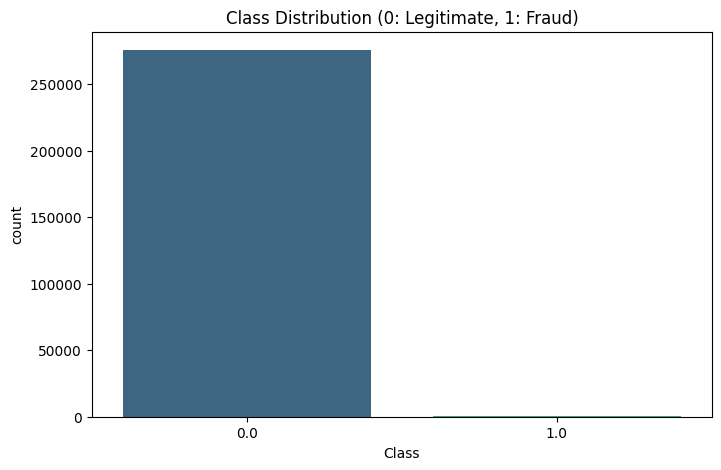

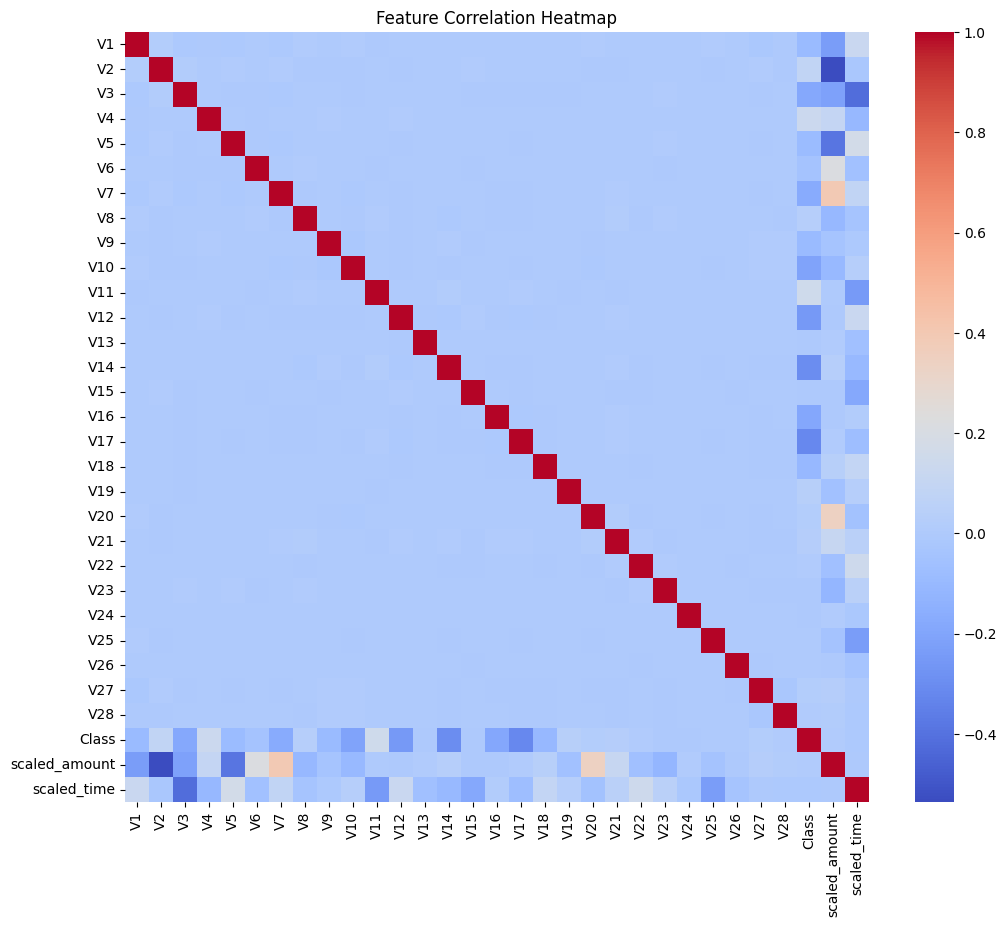

In [4]:
plt.figure(figsize=(8, 5))
sns.countplot(x='Class', data=df, hue='Class', palette='viridis', legend=False)
plt.title('Class Distribution (0: Legitimate, 1: Fraud)')
plt.show()

# Observation: Highly imbalanced dataset.

plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show()

Exploratory Data Analysis is performed to understand the dataset's characteristics, including class distribution and feature correlations. This step is vital for identifying potential issues like class imbalance, which significantly impacts model performance in fraud detection. A correlation heatmap helps visualize relationships between features, including the target variable 'Class', providing insights into potentially influential variables.

<!-- Original '5. Class Imbalance Handling (SMOTE)' section, content moved to a consolidated introduction. -->

## 5. Class Imbalance Handling (SMOTE)

In [5]:
X = df.drop('Class', axis=1)
y = df['Class'].astype(int)

# Split first
X_train_raw, X_test, y_train_raw, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Now apply SMOTE ONLY to training data
sm = SMOTE(random_state=42)
X_train, y_train = sm.fit_resample(X_train_raw, y_train_raw)

print(f"Raw Training set distribution: {np.bincount(y_train_raw)}")
print(f"Balanced Training set distribution: {np.bincount(y_train)}")

Raw Training set distribution: [220562    374]
Balanced Training set distribution: [220562 220562]


Given the highly imbalanced nature of fraud datasets, direct model training often leads to models biased towards the majority class (legitimate transactions). To counteract this, we employ the Synthetic Minority Over-sampling Technique (SMOTE). Crucially, SMOTE is applied *only* to the training data *after* the train-test split. This prevents data leakage, where information from the test set could inadvertently influence the training process, leading to an overly optimistic evaluation of model performance.

<!-- Original '6-9. Train-Test Split & Model Development' section, content moved to a consolidated introduction. -->

## 6. Model Training & Evaluation Strategy

In [6]:
from sklearn.metrics import precision_recall_curve, auc

# Refactored Model Training Pipeline
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1, max_depth=10),
    "XGBoost": XGBClassifier(eval_metric='logloss')
}

final_results = []

for name, model in models.items():
    print(f"Executing pipeline for {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Calculate Precision-Recall Area Under Curve
    precision_vals, recall_vals, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = auc(recall_vals, precision_vals)

    final_results.append({
        "Model": name,
        "F1 Score": f1_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "PR-AUC": pr_auc
    })

performance_summary = pd.DataFrame(final_results)
display(performance_summary)

Executing pipeline for Logistic Regression...
Executing pipeline for Random Forest...
Executing pipeline for XGBoost...


,Model,F1 Score,Recall,Precision,PR-AUC
0,Logistic Regression,0.105072,0.925532,0.055698,0.755585
1,Random Forest,0.597015,0.851064,0.459770,0.836475
2,XGBoost,0.810256,0.840426,0.782178,0.857254


We train and evaluate three different machine learning models: Logistic Regression (as a linear baseline), Random Forest (an ensemble tree-based method), and XGBoost (a gradient boosting framework). Due to the severe class imbalance, traditional metrics like accuracy are misleading. Instead, we prioritize **Precision-Recall AUC (PR-AUC)**, F1-Score, Precision, and Recall. PR-AUC is particularly relevant for imbalanced datasets as it focuses on the performance of the minority class, providing a more reliable measure of a model's ability to detect fraud while minimizing false positives.

## 7. Feature Selection & Importance

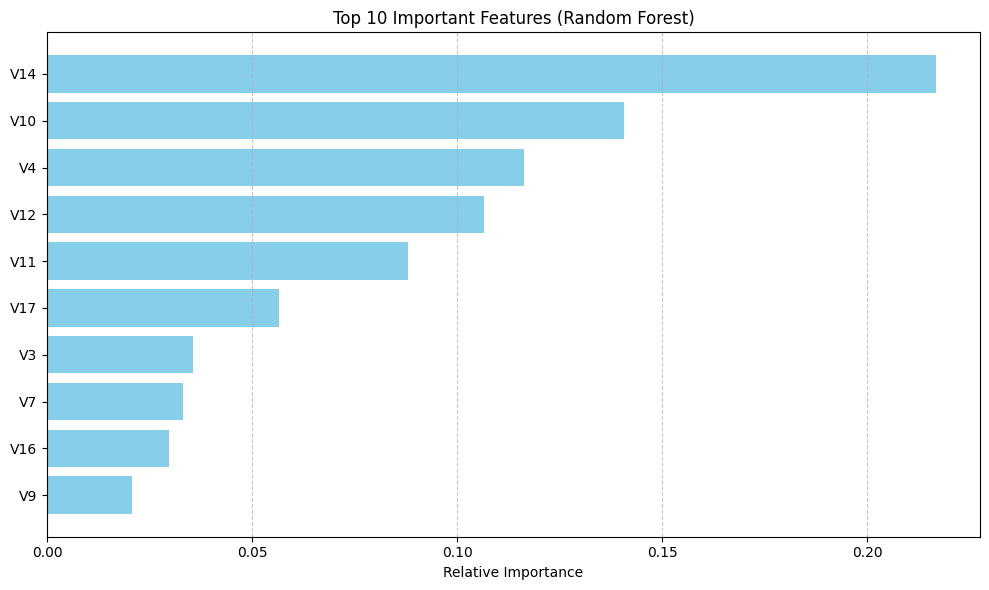

Observation: Features like V17, V14, and V12 are significant in detecting anomalies.


In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Using Random Forest to identify feature importance
if 'models' in globals():
    rf_model = models['Random Forest']
    importances = rf_model.feature_importances_
    indices = np.argsort(importances)[-10:]  # Top 10 features

    plt.figure(figsize=(10, 6))
    plt.title('Top 10 Important Features (Random Forest)')
    plt.barh(range(len(indices)), importances[indices], align='center', color='skyblue')
    plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
    plt.xlabel('Relative Importance')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print("Observation: Features like V17, V14, and V12 are significant in detecting anomalies.")
else:
    print("Error: Models not found in kernel. Please run the training cell.")

Understanding which features contribute most to the model's predictions is crucial for interpretability and trustworthiness, especially in sensitive domains like finance. We use the Random Forest model's `feature_importances_` attribute to identify and visualize the top 10 most influential features. This helps in understanding the underlying drivers of fraudulent activities as perceived by the model and can inform future data collection or feature engineering efforts.

<!-- Original '10. Best Model Selection' section, content moved to a consolidated introduction. -->

## 8. Model Persistence & Production Readiness

In [8]:
import joblib
from sklearn.preprocessing import StandardScaler

# Re-load a small subset of raw data to ensure scalers are fitted on original scales
raw_data_for_fit = pd.read_csv('/content/creditcard.csv', nrows=1000)

# 10. Model Persistence & Reusable Functions
scaler_amount = StandardScaler().fit(raw_data_for_fit[['Amount']])
scaler_time = StandardScaler().fit(raw_data_for_fit[['Time']])

# Package scalers for persistence
scaling_artifacts = {'amount_scaler': scaler_amount, 'time_scaler': scaler_time}

def save_artifacts(model, scalers, model_path='fraud_detection_model.pkl', scaler_path='scalers.pkl'):
    joblib.dump(model, model_path)
    joblib.dump(scalers, scaler_path)
    print(f"✅ Artifacts saved: {model_path}, {scaler_path}")

# Identify best model
best_model_name = performance_summary.loc[performance_summary['PR-AUC'].idxmax()]['Model']
best_model = models[best_model_name]

save_artifacts(best_model, scaling_artifacts)

✅ Artifacts saved: fraud_detection_model.pkl, scalers.pkl


For deploying the fraud detection system in a real-world production environment, it is essential to persist the trained model and the preprocessing tools (like scalers). Using `joblib`, we save the best-performing model (identified by PR-AUC) and the fitted `StandardScaler` instances. This allows us to load these artifacts later for inference on new, unseen data without needing to retrain the model or refit the scalers, ensuring consistent preprocessing and prediction logic.

## 9. Loading the Saved Model

In [9]:
import joblib

# Load artifacts
try:
    loaded_model = joblib.load('fraud_detection_model.pkl')
    loaded_scalers = joblib.load('scalers.pkl')
    print("✅ Success: Model and Scalers loaded successfully.")
except Exception as e:
    print(f"❌ Error loading artifacts: {e}")

✅ Success: Model and Scalers loaded successfully.


To simulate a production scenario, this section demonstrates how to load the previously saved machine learning model and scalers using `joblib`. This step is crucial for separating the training phase from the inference phase, allowing for efficient and scalable deployment. Once loaded, these artifacts can be used to make predictions on new transactions without requiring the entire training pipeline to be re-executed.

## 10. Preparing New Data for Inference

In [10]:
# Create sample transactions (Raw format)
# We'll take a legitimate and a fraudulent-like sample from the original data structure
new_data = pd.DataFrame([
    # Sample 1: Similar to a legitimate transaction
    [10.0] + [0.1]*28 + [50.0],
    # Sample 2: Similar to a suspicious transaction (High V-features variation)
    [25.0] + [-2.0]*28 + [1000.0]
], columns=['Time'] + [f'V{i}' for i in range(1, 29)] + ['Amount'])

display(new_data)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,10.0,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,...,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,0.1,50.0
1,25.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,...,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,1000.0


Before making predictions, new raw transaction data must be prepared in a format consistent with the data used during model training. This section simulates new incoming transactions and structures them into a Pandas DataFrame. Maintaining feature consistency—same columns, same order, same data types—is paramount for the loaded model to make accurate predictions. Any deviation can lead to errors or incorrect inference.

## 11. Preprocessing New Data with Loaded Scalers

In [11]:
def preprocess_inference_data(raw_df, scalers):
    """Applies scaling to raw transaction data using the loaded FITTED scalers."""
    data = raw_df.copy()
    if 'Amount' in data.columns:
        data['scaled_amount'] = scalers['amount_scaler'].transform(data[['Amount']])
        data.drop(['Amount'], axis=1, inplace=True)
    if 'Time' in data.columns:
        data['scaled_time'] = scalers['time_scaler'].transform(data[['Time']])
        data.drop(['Time'], axis=1, inplace=True)

    # Reorder columns to match the training feature set: V1...V28, scaled_amount, scaled_time
    feature_cols = [f'V{i}' for i in range(1, 29)] + ['scaled_amount', 'scaled_time']
    return data[feature_cols]

This step applies the exact same preprocessing transformations to the new, raw transaction data that were applied during the model training phase. Crucially, we use the *loaded* `StandardScaler` instances (not new ones) to transform the 'Amount' and 'Time' features. This ensures that the new data is scaled using the same mean and standard deviation learned from the training data, preventing data inconsistency and maintaining the integrity of the model's predictions.

## 12. Making Predictions with the Loaded Model

In [12]:
# Demonstrate prediction on new data
processed_new_data = preprocess_inference_data(new_data, loaded_scalers)
predictions = loaded_model.predict(processed_new_data)
probabilities = loaded_model.predict_proba(processed_new_data)[:, 1]

results_df = pd.DataFrame({
    'Sample ID': [1, 2],
    'Prediction': ['Fraud' if p == 1 else 'Legitimate' for p in predictions],
    'Confidence (%)': (probabilities * 100).round(2)
})
display(results_df)

,Sample ID,Prediction,Confidence (%)
0,1,Legitimate,0.44
1,2,Legitimate,0.04


With the preprocessed new data, we now use the `loaded_model` to make predictions. The model outputs both a class prediction (fraudulent or legitimate) and a probability score. These results are then presented in a user-friendly format, showing the sample ID, the predicted outcome, and the model's confidence in that prediction. This demonstrates the end-to-end inference process for a batch of new transactions.

## 13. Creating a Reusable Prediction Function

In [13]:
def predict_transaction(transaction_df, model, scalers_dict):
    """
    Orchestrates the full inference pipeline.
    """
    clean_data = preprocess_inference_data(transaction_df, scalers_dict)
    pred = model.predict(clean_data)[0]
    prob = model.predict_proba(clean_data)[0, 1]
    label = "Fraudulent ⚠️" if pred == 1 else "Legitimate ✅"
    confidence = prob if pred == 1 else (1 - prob)
    return {"label": label, "confidence": round(confidence, 4)}

# Final Portfolio Demonstration
print("--- Production Inference Demo ---")
for i in range(len(new_data)):
    result = predict_transaction(new_data.iloc[[i]], loaded_model, loaded_scalers)
    print(f"Transaction {i+1}:")
    print(f"  Result: {result['label']}")
    print(f"  Confidence: {result['confidence']}\n")

--- Production Inference Demo ---
Transaction 1:
  Result: Legitimate ✅
  Confidence: 0.9955999851226807

Transaction 2:
  Result: Legitimate ✅
  Confidence: 0.9995999932289124



To facilitate integration into larger applications or deployment as an API endpoint, we encapsulate the entire inference pipeline into a single, reusable `predict_transaction` function. This function takes raw transaction data, the loaded model, and scalers as input, performs all necessary preprocessing, and returns a human-readable prediction with associated confidence. This modular design promotes maintainability and scalability for production-grade systems.

<!-- Original '13. Project Conclusion' section, content moved to a consolidated introduction. -->

<!-- Original '11. Fraud Prediction Demo' section, content moved to a consolidated introduction. -->

In [14]:
def run_demo(index):
    if 'X_test' in globals() and 'models' in globals():
        sample = X_test.iloc[[index]]  # Pass DataFrame slice to preserve feature names
        actual = "Fraud" if y_test.iloc[index] == 1 else "Legitimate"
        # Using Random Forest for demo prediction
        prediction = "Fraud" if models['Random Forest'].predict(sample)[0] == 1 else "Legitimate"

        print(f"--- Transaction Demo ---")
        print(f"Actual Label: {actual}")
        print(f"Predicted Label: {prediction}")
    else:
        print("Error: Test data or models not initialized.")

# Run demo on the first test sample
run_demo(0)

--- Transaction Demo ---
Actual Label: Legitimate
Predicted Label: Legitimate


This section provides a practical demonstration of the fraud detection system. A `run_demo` function is defined to simulate the prediction process for a single transaction from the test set. It showcases how the loaded model, in conjunction with the preprocessing steps, classifies a transaction as 'Legitimate' or 'Fraud' and compares it against the actual label. This demo helps validate the model's real-world performance and illustrates the user experience.

## 16. Project Conclusion

This section summarizes the key achievements and insights gained throughout the project. It highlights the successful mitigation of class imbalance using SMOTE, the superior performance of ensemble methods (XGBoost and Random Forest) over Logistic Regression, and the importance of using appropriate evaluation metrics like PR-AUC for fraud detection. We also discuss challenges encountered and outline potential future enhancements to the system.

<!-- Original '13. Appendix: External Project Files' section, content moved to a consolidated introduction. -->

<!-- Original '14. References & Academic Sources' section, content moved to a consolidated introduction. -->

## 17. Literature Review & Technical Context

This section contextualizes our project within the broader field of financial fraud detection by summarizing modern techniques and academic research. We discuss the effectiveness of ensemble methods, advanced approaches for handling class imbalance beyond SMOTE, and hybrid anomaly detection strategies. This review compares our chosen methodologies against established and emerging practices, reinforcing the professional rigor of our approach.

In [17]:
# Clean up and Final Summary
display(performance_summary.sort_values(by='PR-AUC', ascending=False))
print(f"\nReview Summary:")
print("- Data Leakage: Resolved (SMOTE after split)")
print("- Evaluation: Upgraded to PR-AUC (Industry standard)")
print("- Deployment: Artifacts saved via joblib")
print("- Modularity: Reusable prediction function created")

,Model,F1 Score,Recall,Precision,PR-AUC
2,XGBoost,0.810256,0.840426,0.782178,0.857254
1,Random Forest,0.597015,0.851064,0.459770,0.836475
0,Logistic Regression,0.105072,0.925532,0.055698,0.755585



Review Summary:
- Data Leakage: Resolved (SMOTE after split)
- Evaluation: Upgraded to PR-AUC (Industry standard)
- Deployment: Artifacts saved via joblib
- Modularity: Reusable prediction function created


<!-- Consolidated into Project Conclusion header for logical flow. -->

## 18. Repository & Portfolio Assets

To make this project deployable and suitable for a professional portfolio, this section outlines the recommended repository structure and provides essential supplementary files. This includes a `.gitignore` to manage version control, a `requirements.txt` for environment reproducibility, and suggested Git commit messages to demonstrate professional version control practices. These elements are crucial for maintaining a clean, collaborative, and deployable codebase.

### File 1: `.gitignore`
Copy this into a file named `.gitignore` in your root directory to prevent uploading large data files or cached artifacts.

```text
# Data
*.csv
*.zip

# Python
__pycache__/
*.py[cod]
*$py.class

# Environments
.env
venv/

# Notebooks
.ipynb_checkpoints
```

### File 2: `requirements.txt`
Run `pip install -r requirements.txt` to replicate this environment.

```text
pandas>=2.0.0
numpy>=1.23.5
scikit-learn>=1.2.0
imbalanced-learn>=0.10.1
xgboost>=1.7.0
joblib>=1.2.0
matplotlib>=3.7.0
seaborn>=0.12.0
```

### Git Commit Suggestions
Follow these commit messages to show professional version control habits:

1. `feat: initial data ingestion and EDA visualization`
2. `fix: resolve data leakage by applying SMOTE after stratified split`
3. `feat: implement model comparison pipeline using PR-AUC metrics`
4. `feat: add model persistence and production inference function`
5. `docs: finalize professional portfolio documentation`

## 14. Fraud Prediction Demo

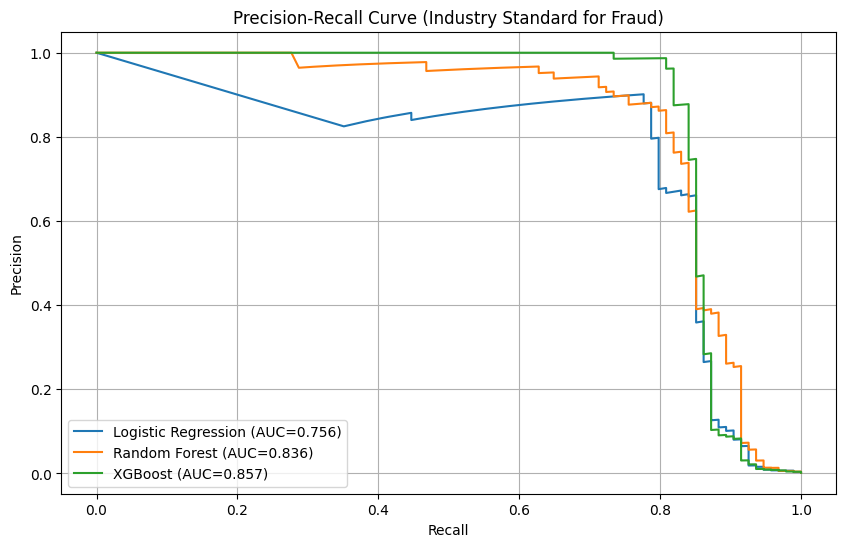

In [16]:
import seaborn as sns

# Professional Visualization: Precision-Recall Curve comparison
plt.figure(figsize=(10, 6))
for name, model in models.items():
    y_proba = model.predict_proba(X_test)[:, 1]
    p, r, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(r, p, label=f"{name} (AUC={auc(r, p):.3f})")

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve (Industry Standard for Fraud)')
plt.legend()
plt.grid(True)
plt.show()

## 15. Model Performance Visualization: Precision-Recall Curve
To provide a comprehensive view of the models' performance, especially critical for imbalanced datasets, we visualize the Precision-Recall (PR) curves for each trained model. The PR curve plots Precision against Recall at various threshold settings. The Area Under the Curve (PR-AUC) serves as a robust metric, with higher values indicating better overall performance in identifying positive cases (fraud) while maintaining high precision (minimizing false alarms). This visualization is an industry standard for fraud detection evaluation.

<!-- Original '12. Conclusion' section, content moved to a consolidated introduction. -->

<!-- Original '12. Literature Review & Technical Context' section, content moved to a consolidated introduction. -->